In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from google.colab import files

uploaded = files.upload()

Saving survey.csv to survey (1).csv


In [11]:
df = pd.read_csv('survey.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [12]:
df.shape

(1259, 27)

In [13]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [15]:
# Check missing values in each column
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [16]:
df.isnull().sum()


,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [17]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [18]:
# Check basic statistics of Age
df['Age'].describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [19]:
# Find unrealistic ages
invalid_age = df[(df['Age'] < 18) | (df['Age'] > 100)]

invalid_age[['Age', 'Gender', 'Country']]

,Age,Gender,Country
143,-29,Male,United States
364,329,Male,United States
390,99999999999,All,Zimbabwe
715,-1726,male,United Kingdom
734,5,Male,United States
989,8,A little about you,"Bahamas, The"
1090,11,male,United States
1127,-1,p,United States


In [20]:
# Remove unrealistic age values
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

# Check the new number of rows
df.shape


(1251, 27)

In [21]:
# Check Age statistics after cleaning
df['Age'].describe()

,Age
count,1251.000000
mean,32.076739
std,7.288272
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


In [22]:
# Check unique Gender values and their counts
df['Gender'].value_counts()

,count
Gender,
Male,612
male,204
Female,121
M,116
female,62
F,38
m,34
f,15
Make,4


In [23]:
# Display all unique gender values
sorted(df['Gender'].unique())

['Agender',
 'Androgyne',
 'Cis Female',
 'Cis Male',
 'Cis Man',
 'Enby',
 'F',
 'Femake',
 'Female',
 'Female ',
 'Female (cis)',
 'Female (trans)',
 'Genderqueer',
 'Guy (-ish) ^_^',
 'M',
 'Mail',
 'Make',
 'Mal',
 'Male',
 'Male ',
 'Male (CIS)',
 'Male-ish',
 'Malr',
 'Man',
 'Nah',
 'Neuter',
 'Trans woman',
 'Trans-female',
 'Woman',
 'cis male',
 'cis-female/femme',
 'f',
 'femail',
 'female',
 'fluid',
 'm',
 'maile',
 'male',
 'male leaning androgynous',
 'msle',
 'non-binary',
 'ostensibly male, unsure what that really means',
 'queer',
 'queer/she/they',
 'something kinda male?',
 'woman']

In [24]:
# Clean and standardize Gender values

def clean_gender(gender):
    gender = str(gender).strip().lower()

    if gender in ['male', 'm', 'make', 'man', 'mail', 'mal', 'malr', 'maile', 'msle']:
        return 'Male'

    elif gender in ['female', 'f', 'woman', 'femake', 'femail', 'femal']:
        return 'Female'

    else:
        return 'Other'


df['Gender'] = df['Gender'].apply(clean_gender)

# Check the cleaned Gender values
df['Gender'].value_counts()

,count
Gender,
Male,980
Female,244
Other,27


In [25]:
# Check country values and their counts
df['Country'].value_counts()

,count
Country,
United States,746
United Kingdom,184
Canada,72
Germany,45
Netherlands,27
Ireland,27
Australia,21
France,13
India,10


In [26]:
# Top 10 countries by number of respondents
df['Country'].value_counts().head(10)

,count
Country,
United States,746
United Kingdom,184
Canada,72
Germany,45
Netherlands,27
Ireland,27
Australia,21
France,13
India,10


In [27]:
# Check self-employed values
df['self_employed'].value_counts(dropna=False)

,count
self_employed,
No,1091
Yes,142
NaN,18


In [28]:
# Fill missing values with the most common value
df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)

# Check again
df['self_employed'].value_counts()

/tmp/ipykernel_2339/2622734543.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)


,count
self_employed,
No,1109
Yes,142


In [29]:
# Check work interference values
df['work_interfere'].value_counts(dropna=False)

,count
work_interfere,
Sometimes,464
NaN,262
Never,212
Rarely,173
Often,140


In [30]:
# Check work interference against treatment
pd.crosstab(df['treatment'], df['work_interfere'], dropna=False)

work_interfere,Never,Often,Rarely,Sometimes,NaN
treatment,,,,,
No,182,21,51,107,258
Yes,30,119,122,357,4


In [31]:
# Replace missing work_interfere values
df['work_interfere'] = df['work_interfere'].fillna('Not Applicable')

# Check the result
df['work_interfere'].value_counts()

,count
work_interfere,
Sometimes,464
Not Applicable,262
Never,212
Rarely,173
Often,140


In [32]:
# Check state values including missing values
df['state'].value_counts(dropna=False).head(20)

,count
state,
NaN,513
CA,138
WA,70
NY,57
TN,45
TX,44
PA,29
OR,29
IL,28


In [33]:
# Fill missing state values
df['state'] = df['state'].fillna('Not Applicable')

# Check the result
df['state'].value_counts().head(20)

,count
state,
Not Applicable,513
CA,138
WA,70
NY,57
TN,45
TX,44
PA,29
OR,29
IL,28


In [34]:
df['comments'].isnull().sum()

np.int64(1090)

In [35]:
df = df.drop(columns=['comments'])

df.shape

(1251, 26)

In [36]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0


In [37]:
df['treatment'].value_counts()

,count
treatment,
Yes,632
No,619


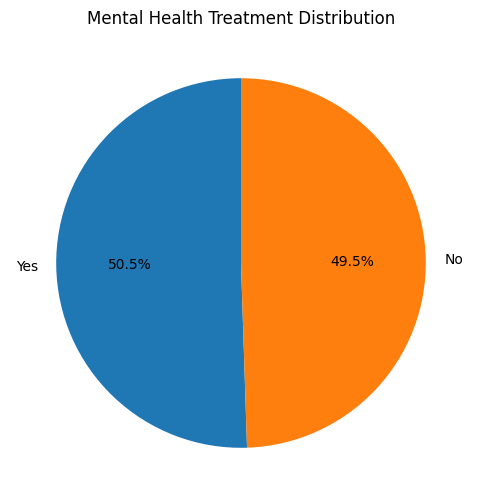

In [40]:
plt.figure(figsize=(6, 6))

df['treatment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Mental Health Treatment Distribution')
plt.ylabel('')
plt.show()

In [41]:
# Find the 10 countries with the highest number of survey respondents
df['Country'].value_counts().head(10)

,count
Country,
United States,746
United Kingdom,184
Canada,72
Germany,45
Netherlands,27
Ireland,27
Australia,21
France,13
India,10


In [42]:
# Compare mental health treatment across the top 10 countries
top_countries = df['Country'].value_counts().head(10).index

df[df['Country'].isin(top_countries)].groupby(
    'Country'
)['treatment'].value_counts()

Country         treatment
Australia       Yes           13
                No             8
Canada          Yes           37
                No            35
France          No            11
                Yes            2
Germany         No            24
                Yes           21
India           No             7
                Yes            3
Ireland         No            14
                Yes           13
Netherlands     No            18
                Yes            9
New Zealand     Yes            5
                No             3
United Kingdom  No            92
                Yes           92
United States   Yes          408
                No           338
Name: count, dtype: int64

In [43]:
# Calculate the percentage of respondents who sought treatment in each top 10 country
country_treatment = (
    df[df['Country'].isin(top_countries)]
    .groupby('Country')['treatment']
    .value_counts(normalize=True)
    .unstack()
)

country_treatment

treatment,No,Yes
Country,,
Australia,0.380952,0.619048
Canada,0.486111,0.513889
France,0.846154,0.153846
Germany,0.533333,0.466667
India,0.700000,0.300000
Ireland,0.518519,0.481481
Netherlands,0.666667,0.333333
New Zealand,0.375000,0.625000
United Kingdom,0.500000,0.500000


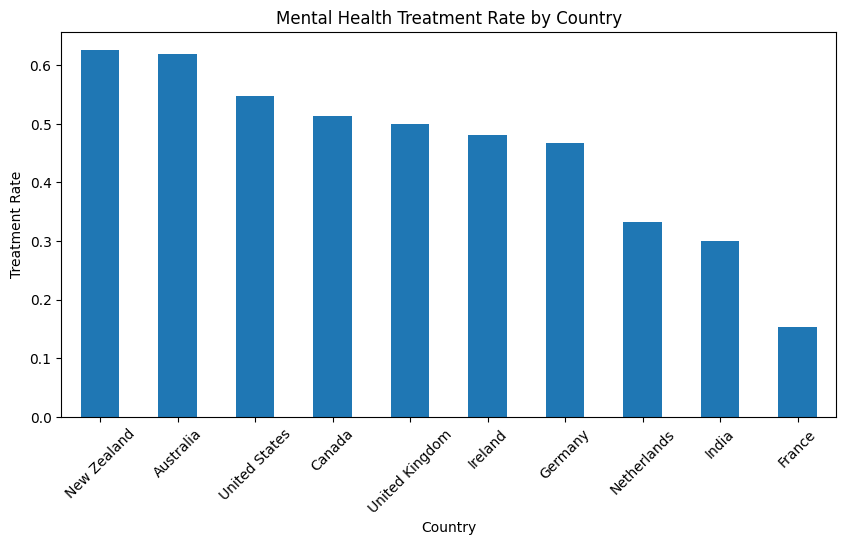

In [44]:
# Create a bar chart to compare treatment rates across the top 10 countries

country_treatment['Yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Mental Health Treatment Rate by Country')
plt.xlabel('Country')
plt.ylabel('Treatment Rate')
plt.xticks(rotation=45)
plt.show()

In [45]:
# Compare mental health attitudes across the top 10 countries
df[df['Country'].isin(top_countries)].groupby(
    'Country'
)['mental_vs_physical'].value_counts()

Country         mental_vs_physical
Australia       No                      8
                Yes                     7
                Don't know              6
Canada          Don't know             33
                No                     20
                Yes                    19
France          Don't know              6
                No                      4
                Yes                     3
Germany         Don't know             19
                Yes                    17
                No                      9
India           Don't know              5
                Yes                     3
                No                      2
Ireland         No                     12
                Don't know             11
                Yes                     4
Netherlands     Yes                    14
                Don't know             10
                No                      3
New Zealand     Don't know              4
                No                      3
                Yes                     1
United Kingdom  Don't know             74
                No                     57
                Yes                    53
United States   Don't know            362
                Yes                   198
                No                    186
Name: count, dtype: int64

In [46]:
# Calculate the percentage of each mental health attitude response by country
country_attitude = (
    df[df['Country'].isin(top_countries)]
    .groupby('Country')['mental_vs_physical']
    .value_counts(normalize=True)
    .unstack()
)

country_attitude

mental_vs_physical,Don't know,No,Yes
Country,,,
Australia,0.285714,0.380952,0.333333
Canada,0.458333,0.277778,0.263889
France,0.461538,0.307692,0.230769
Germany,0.422222,0.200000,0.377778
India,0.500000,0.200000,0.300000
Ireland,0.407407,0.444444,0.148148
Netherlands,0.370370,0.111111,0.518519
New Zealand,0.500000,0.375000,0.125000
United Kingdom,0.402174,0.309783,0.288043


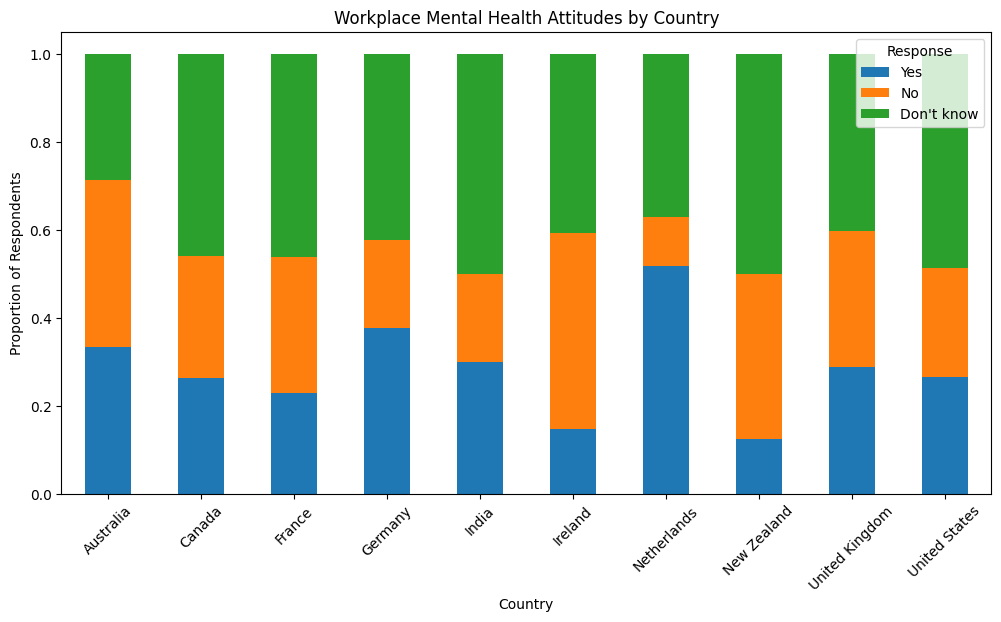

In [47]:
# Create a stacked bar chart to compare workplace mental health attitudes by country

country_attitude[['Yes', 'No', "Don't know"]].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Workplace Mental Health Attitudes by Country')
plt.xlabel('Country')
plt.ylabel('Proportion of Respondents')
plt.xticks(rotation=45)
plt.legend(title='Response')
plt.show()

In [48]:
# Compare mental health treatment based on family history of mental illness
pd.crosstab(df['family_history'], df['treatment'])

treatment,No,Yes
family_history,,
No,492,270
Yes,127,362


In [49]:
# Calculate treatment percentages based on family history
family_treatment_pct = pd.crosstab(
    df['family_history'],
    df['treatment'],
    normalize='index'
) * 100

family_treatment_pct

treatment,No,Yes
family_history,,
No,64.566929,35.433071
Yes,25.971370,74.028630


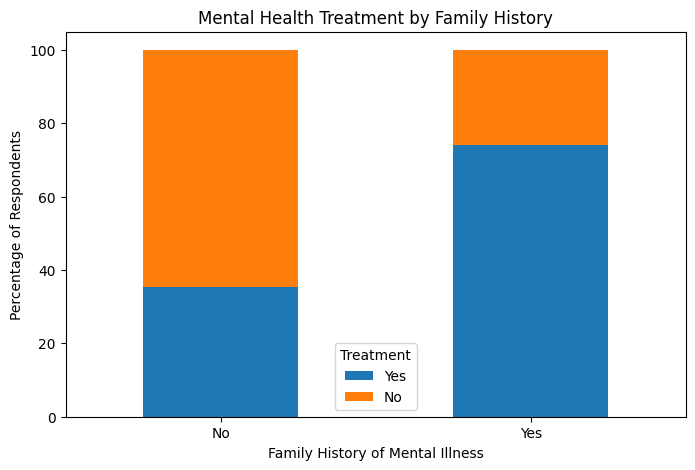

In [50]:
# Create a stacked bar chart to compare treatment by family history

family_treatment_pct[['Yes', 'No']].plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Mental Health Treatment by Family History')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
plt.show()

In [51]:
# Compare mental health treatment based on how much mental health interferes with work
pd.crosstab(df['work_interfere'], df['treatment'])

treatment,No,Yes
work_interfere,,
Never,182,30
Not Applicable,258,4
Often,21,119
Rarely,51,122
Sometimes,107,357


In [52]:
# Calculate treatment percentages based on how much mental health interferes with work
work_treatment_pct = pd.crosstab(
    df['work_interfere'],
    df['treatment'],
    normalize='index'
) * 100

work_treatment_pct

treatment,No,Yes
work_interfere,,
Never,85.849057,14.150943
Not Applicable,98.473282,1.526718
Often,15.000000,85.000000
Rarely,29.479769,70.520231
Sometimes,23.060345,76.939655


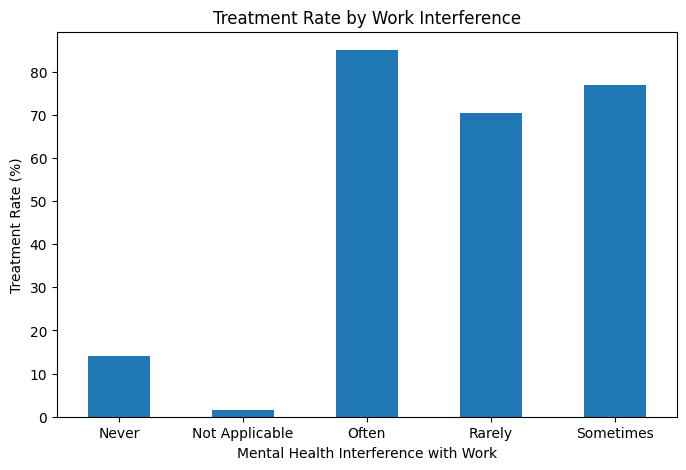

In [53]:
# Create a bar chart to compare treatment rates by work interference

work_treatment_pct['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Treatment Rate by Work Interference')
plt.xlabel('Mental Health Interference with Work')
plt.ylabel('Treatment Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [54]:
# Compare mental health treatment based on employer-provided mental health benefits
pd.crosstab(df['benefits'], df['treatment'])

treatment,No,Yes
benefits,,
Don't know,256,151
No,192,179
Yes,171,302


In [55]:
# Calculate treatment percentages based on employer mental health benefits
benefits_treatment_pct = pd.crosstab(
    df['benefits'],
    df['treatment'],
    normalize='index'
) * 100

benefits_treatment_pct

treatment,No,Yes
benefits,,
Don't know,62.899263,37.100737
No,51.752022,48.247978
Yes,36.152220,63.847780


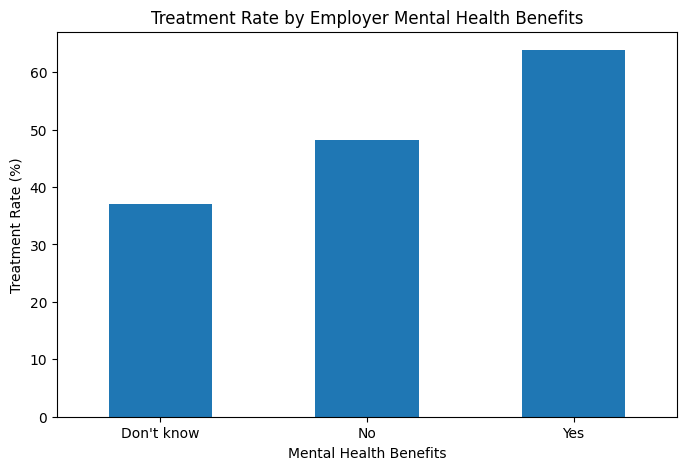

In [56]:
# Create a bar chart to compare treatment rates based on employer mental health benefits

benefits_treatment_pct['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Treatment Rate by Employer Mental Health Benefits')
plt.xlabel('Mental Health Benefits')
plt.ylabel('Treatment Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [57]:
# Compare mental health treatment based on awareness of employer care options
pd.crosstab(df['care_options'], df['treatment'])

treatment,No,Yes
care_options,,
No,293,206
Not sure,190,123
Yes,136,303


In [58]:
# Calculate treatment percentages based on awareness of employer care options
care_treatment_pct = pd.crosstab(
    df['care_options'],
    df['treatment'],
    normalize='index'
) * 100

care_treatment_pct

treatment,No,Yes
care_options,,
No,58.717435,41.282565
Not sure,60.702875,39.297125
Yes,30.979499,69.020501


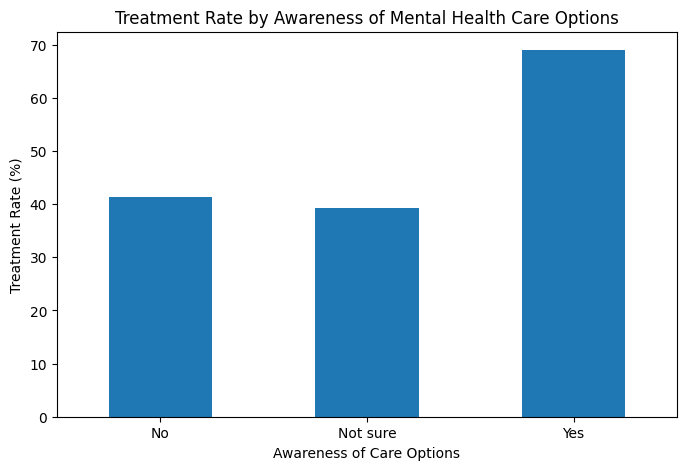

In [59]:
# Create a bar chart to compare treatment rates based on awareness of care options

care_treatment_pct['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Treatment Rate by Awareness of Mental Health Care Options')
plt.xlabel('Awareness of Care Options')
plt.ylabel('Treatment Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [60]:
# Compare mental health treatment based on gender
pd.crosstab(df['Gender'], df['treatment'])

treatment,No,Yes
Gender,,
Female,76,168
Male,536,444
Other,7,20


In [61]:
# Calculate treatment percentages based on gender
gender_treatment_pct = pd.crosstab(
    df['Gender'],
    df['treatment'],
    normalize='index'
) * 100

gender_treatment_pct

treatment,No,Yes
Gender,,
Female,31.147541,68.852459
Male,54.693878,45.306122
Other,25.925926,74.074074


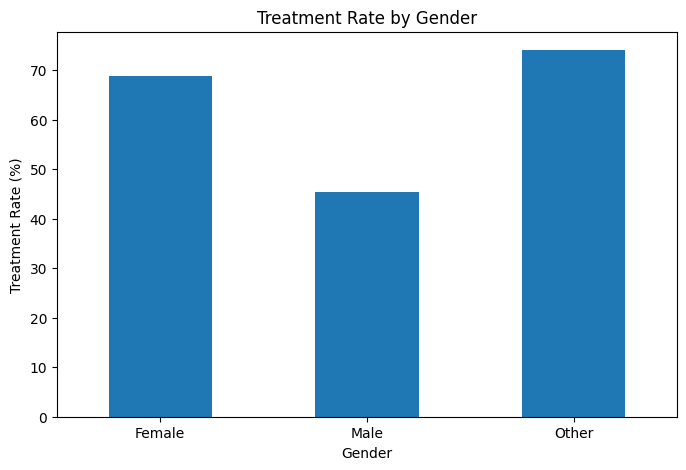

In [62]:
# Create a bar chart to compare treatment rates by gender

gender_treatment_pct['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Treatment Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Treatment Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [63]:
# Compare mental health treatment based on workplace anonymity
pd.crosstab(df['anonymity'], df['treatment'])

treatment,No,Yes
anonymity,,
Don't know,446,369
No,27,37
Yes,146,226


In [64]:
# Calculate treatment percentages based on workplace anonymity
anonymity_treatment_pct = pd.crosstab(
    df['anonymity'],
    df['treatment'],
    normalize='index'
) * 100

anonymity_treatment_pct

treatment,No,Yes
anonymity,,
Don't know,54.723926,45.276074
No,42.187500,57.812500
Yes,39.247312,60.752688


In [65]:
# Compare mental health treatment based on the workplace wellness program
pd.crosstab(df['wellness_program'], df['treatment'])

treatment,No,Yes
wellness_program,,
Don't know,106,81
No,420,417
Yes,93,134


In [66]:
# Calculate treatment percentages based on workplace wellness program
wellness_treatment_pct = pd.crosstab(
    df['wellness_program'],
    df['treatment'],
    normalize='index'
) * 100

wellness_treatment_pct

treatment,No,Yes
wellness_program,,
Don't know,56.684492,43.315508
No,50.179211,49.820789
Yes,40.969163,59.030837


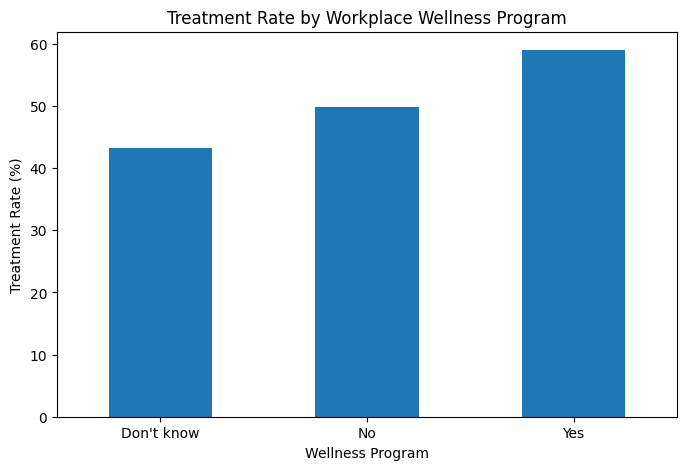

In [67]:
# Create a bar chart to compare treatment rates based on workplace wellness programs

wellness_treatment_pct['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Treatment Rate by Workplace Wellness Program')
plt.xlabel('Wellness Program')
plt.ylabel('Treatment Rate (%)')
plt.xticks(rotation=0)
plt.show()